In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
g = 9.81
tol=1e-5
def newton_raphson(h, omega, tol):

  def fenton_mckee(h, omega):
    y = (omega**2) * h / g
    y_34 = y ** 0.75
    coth_y34 = 1 / np.tanh(y_34)
    xi = y * (coth_y34 ** (2/3))
    return xi

  def ecuacion_dispersion(h, omega, xi):
    primer_termino = (omega**2) * (h/g)
    segundo_termino = xi * np.tanh(xi)
    return primer_termino - segundo_termino

  def ecuacion_dispersion_derivada(h, omega, xi):
    cos_hip = np.cosh(xi)
    denominador_primer_termino= cos_hip**2
    primer_termino = (xi/denominador_primer_termino)
    segundo_termino = np.tanh(xi)
    return -primer_termino -segundo_termino

  xi = fenton_mckee(h, omega)

  while True:
    f = ecuacion_dispersion(h, omega, xi)
    df = ecuacion_dispersion_derivada(h, omega, xi)
    x_nuevo = xi - (f / df)
    if abs(x_nuevo - xi) < tol:
      break
    xi = x_nuevo

  k = xi / h
  L = 2 * np.pi / k

  return xi

def guo(h, omega):
    beta = 2.4908
    sqrt_gh = np.sqrt(g * h)
    x = (h * omega) / sqrt_gh

    x_exponente_beta = np.power(x, beta)
    exp_termino = np.exp(-x_exponente_beta)
    base = 1.0 - exp_termino
    exponente_termino = np.power(base, -1.0 / beta)

    x_squared = np.power(x, 2)
    x = x_squared * exponente_termino

    L = (2.0 * np.pi * h) / x
    return x

def hunt(h, omega):
    D_COEFICIENTES = [0.666, 0.355, 0.1608465608, 0.0632098765, 0.0217540484, 0.0065407983]

    y = (np.power(omega, 2) * h) / g
    sum_term = 0.0
    y_power_n = y
    for i in range(len(D_COEFICIENTES)):
        sum_term = sum_term + D_COEFICIENTES[i] * y_power_n
        if i < len(D_COEFICIENTES) - 1:
            y_power_n = y_power_n * y

    denominador = 1.0 + sum_term

    x_squared = np.power(y, 2) + y / denominador

    x = np.sqrt(x_squared)

    k = x / h
    L = (2.0 * np.pi) / k

    return x

def secante(h, omega, tol):

    def fenton_mckee(h, omega):
        y = (omega**2) * h / g
        y_34 = y ** 0.75
        coth_y34 = 1 / np.tanh(y_34)
        x1 = y * (coth_y34 ** (2/3))
        return x1

    def ecuacion_dispersion(h, omega, xi):
        primer_termino = (omega**2) * (h/g)
        segundo_termino = xi * np.tanh(xi)
        return primer_termino - segundo_termino

    T = (2*np.pi)/omega
    L = (g*(T**2))/(2*np.pi)
    k = (2*np.pi)/L
    x0 = k*h
    x1 = fenton_mckee(h, omega)

    while True:
        fx1 = ecuacion_dispersion(h, omega, x1)
        fx0 = ecuacion_dispersion(h, omega, x0)

        denominador = fx1 - fx0

        epsilon = 1e-15
        if abs(denominador) < epsilon:
            break

        x2 = x1 - (fx1 * (x1 - x0)) / denominador

        x0 = x1
        x1 = x2

        if abs(x1 - x0) < tol:
            break
    return x1

def eckart(h, omega):
  tanh = np.sqrt(np.tanh(((omega**2)*h)/g))
  denominador = g*tanh
  numerador = omega**2
  k = (numerador/denominador)
  x = k*h
  return x

h_input = 1
omega_input = 1000

print(newton_raphson(h_input, omega_input, tol))
print(guo(h_input, omega_input))
print(hunt(h_input, omega_input))
print(secante(h_input, omega_input, tol))
print(eckart(h_input, omega_input))

101936.7991845056
101936.79918450561
101936.7991845056
101936.7991845056
101936.7991845056


<ipython-input-2-4b19603d0cd1>:18: RuntimeWarning: overflow encountered in cosh
  cos_hip = np.cosh(xi)


In [ ]:
h = 1

dx = 0.001
x_inicial = 0.01
x_final = 10 + x_inicial
x_array = np.arange(x_inicial, x_final + dx, dx)

omega_array = (x_array*np.sqrt(g))/(np.sqrt(h))

#arrays newton rapshon
kh_array_newton_raphson_exacto = np.zeros_like(x_array)

for i in range(len(x_array)):
  x = newton_raphson(h, omega_array[i], 1e-15)
  kh_array_newton_raphson_exacto[i] = x

#Límite aguas someras
omega_lim_somera = ((2*np.pi)/20)*np.sqrt(g*h)
x_lim_somera = (omega_lim_somera*h)/(np.sqrt(g*h))
#Límite aguas profundas
omega_lim_profunda = np.sqrt(np.pi*g)
x_lim_profunda = (omega_lim_profunda*h)/(np.sqrt(g*h))

print(x_lim_somera)
print(x_lim_profunda)

0.3141592653589793
1.772453850905516


In [ ]:
#Error relativo
def error_relativo(Y_aprox, Y_verdadero):
  return ((Y_aprox - Y_verdadero) / Y_verdadero)*100

#error y=x
error_array_y_x = np.zeros_like(x_array)
for i in range(len(x_array)):
  x = x_array[i]
  error_array_y_x[i] = error_relativo(x, kh_array_newton_raphson_exacto[i])

#error y=x**2
error_array_y_x2 = np.zeros_like(x_array)
for i in range(len(x_array)):
  x = x_array[i]**2
  error_array_y_x2[i] = error_relativo(x, kh_array_newton_raphson_exacto[i])

#arrays newton rapshon tol 10e-5
kh_array_newton_raphson = np.zeros_like(x_array)
error_array_newton_raphson = np.zeros_like(x_array)
for i in range(len(x_array)):
  x = newton_raphson(h, omega_array[i], tol)
  error_array_newton_raphson[i] = error_relativo(x, kh_array_newton_raphson_exacto[i])
  kh_array_newton_raphson[i] = x

#arrays guo
kh_array_guo = np.zeros_like(x_array)
error_array_guo = np.zeros_like(x_array)
for i in range(len(x_array)):
  x = guo(h, omega_array[i])
  error_array_guo[i] = error_relativo(x, kh_array_newton_raphson_exacto[i])
  kh_array_guo[i] = x

#arrays hunt
kh_array_hunt = np.zeros_like(x_array)
error_array_hunt = np.zeros_like(x_array)
for i in range(len(x_array)):
  x = hunt(h, omega_array[i])
  error_array_hunt[i] = error_relativo(x, kh_array_newton_raphson_exacto[i])
  kh_array_hunt[i] = x

#arrya eckart
kh_array_eckart = np.zeros_like(x_array)
error_array_eckart = np.zeros_like(x_array)
for i in range(len(x_array)):
  x = eckart(h, omega_array[i])
  error_array_eckart[i] = error_relativo(x, kh_array_newton_raphson_exacto[i])
  kh_array_eckart[i] = x

#Error secante
kh_array_secante = np.zeros_like(x_array)
error_array_secante = np.zeros_like(x_array)
for i in range(len(x_array)):
  x = secante(h, omega_array[i], tol)
  error_array_secante[i] = error_relativo(x, kh_array_newton_raphson_exacto[i])
  kh_array_secante[i] = x

max_error_newton_raphson = max(abs(error_array_newton_raphson))
max_error_guo = max(abs(error_array_guo))
max_error_hunt = max(abs(error_array_hunt))
max_error_eckart = max(abs(error_array_eckart))
max_error_secante = max(abs(error_array_secante))




0.024032785580888713
0.753160360484685
0.18640285168718534
4.979783235993428
0.014424384766293931


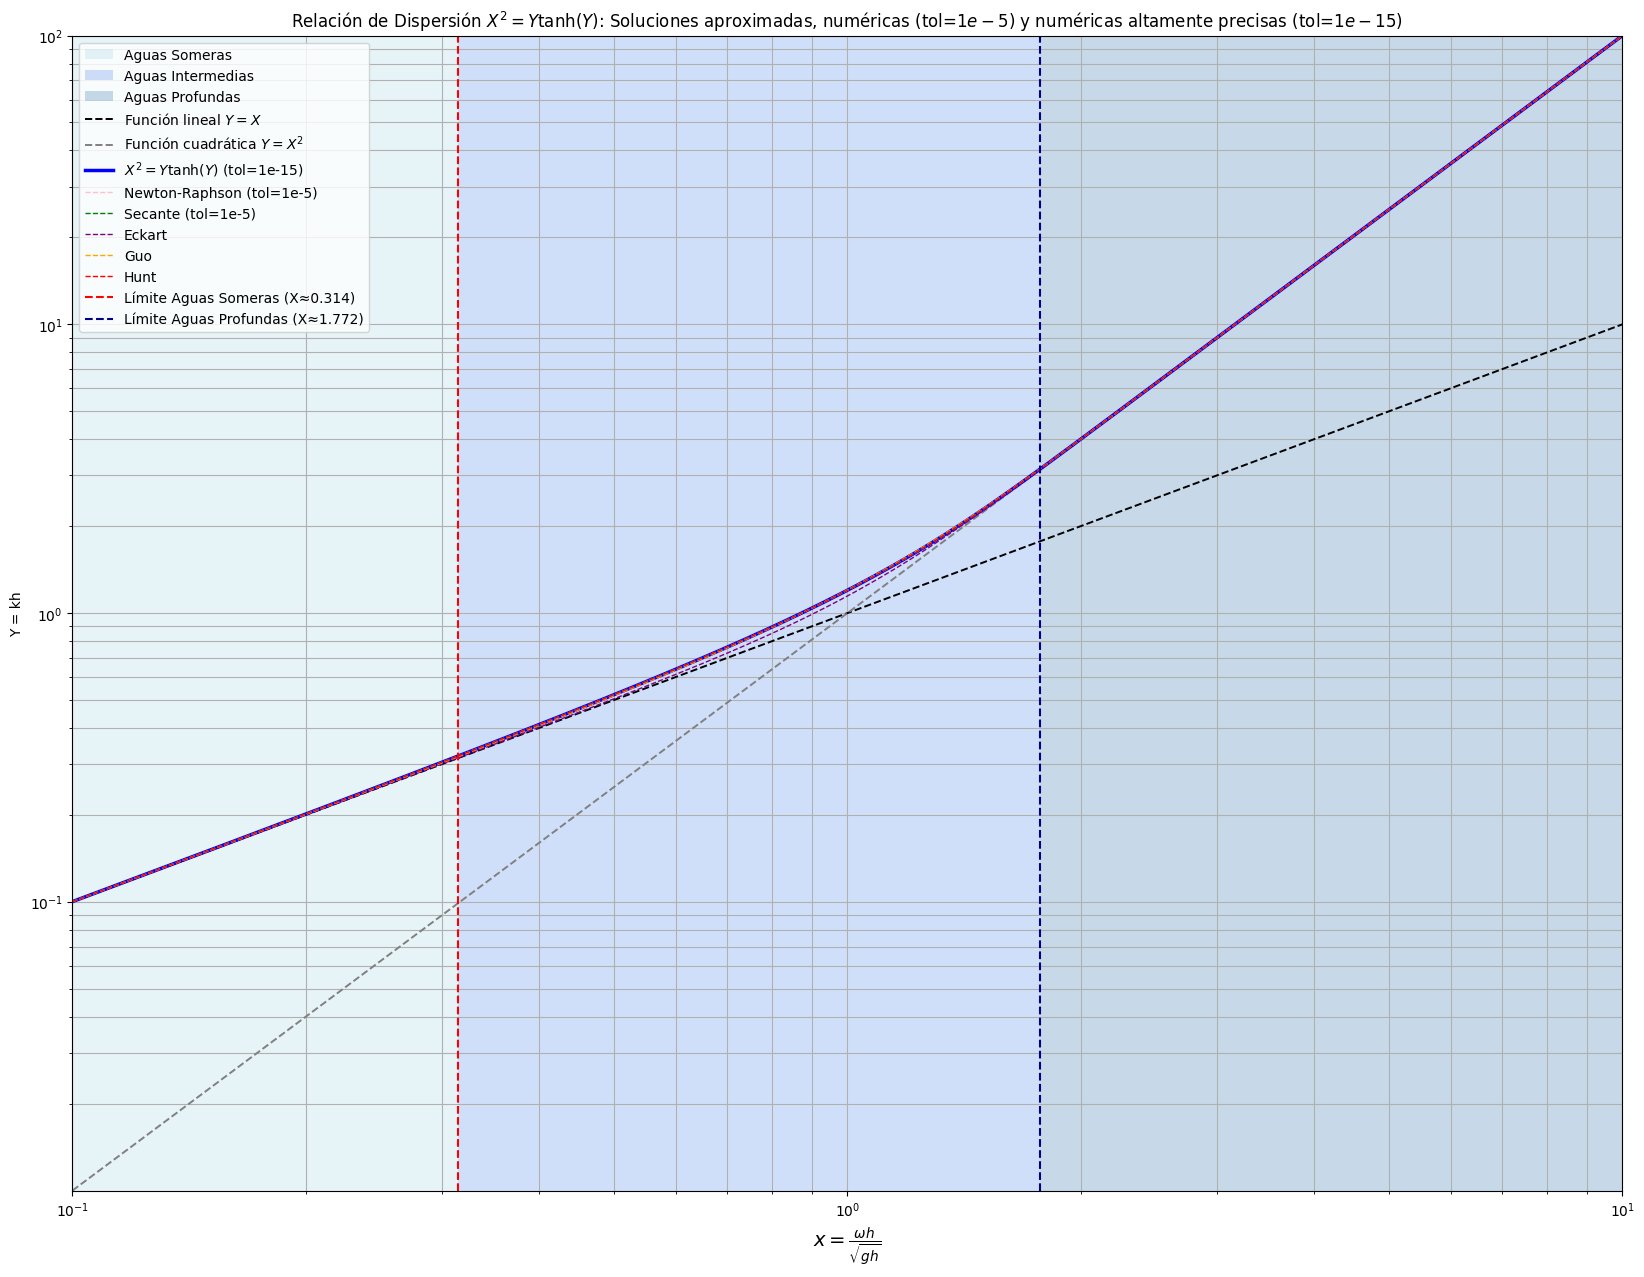

In [ ]:
plt.figure(figsize=(20, 15))

plt.axvspan(0.1, x_lim_somera, facecolor='lightblue', alpha=0.3, label='Aguas Someras')
plt.axvspan(x_lim_somera, x_lim_profunda, facecolor='cornflowerblue', alpha=0.3, label='Aguas Intermedias')
plt.axvspan(x_lim_profunda, 10, facecolor='steelblue', alpha=0.3, label='Aguas Profundas')

plt.plot(x_array, x_array, label='Función lineal $Y = X$', linewidth=1.4, linestyle='--', color="black")
plt.plot(x_array, x_array**2, label='Función cuadrática $Y = {X}^2$', linewidth=1.4, linestyle='--', color="grey")
plt.plot(x_array, kh_array_newton_raphson_exacto, label=r"$X^2 = Y \tanh(Y)$ (tol=1e-15)", linewidth=2.5, color="blue")

plt.plot(x_array, kh_array_newton_raphson, label=r"Newton-Raphson (tol=1e-5)", linewidth=1, color="pink", linestyle='--')
plt.plot(x_array, kh_array_secante, label=r"Secante (tol=1e-5)", linewidth=1, color="green", linestyle='--')
plt.plot(x_array, kh_array_eckart, label=r"Eckart", linewidth=1, color="purple", linestyle='--')
plt.plot(x_array, kh_array_guo, label=r"Guo", linewidth=1, color="orange", linestyle='--')
plt.plot(x_array, kh_array_hunt, label=r"Hunt", linewidth=1, color="red", linestyle='--')


plt.xscale('log')
plt.yscale('log')
plt.axvline(x=x_lim_somera, color='red', linestyle='--', label=f'Límite Aguas Someras (X≈{x_lim_somera:.3f})')
plt.axvline(x=x_lim_profunda, color='darkblue', linestyle='--', label=f'Límite Aguas Profundas (X≈{x_lim_profunda:.3f})')
plt.xlabel(r'$x = \frac{\omega h}{\sqrt{gh}}$', fontsize=14)
plt.ylabel('Y = kh')
plt.title(r'Relación de Dispersión $X^2 = Y \tanh(Y)$: Soluciones aproximadas, numéricas (tol=$1e-5$) y numéricas altamente precisas (tol=$1e-15$)')
plt.xlim(0.1, 10)
plt.ylim(kh_array_newton_raphson_exacto.min(), 100)
plt.legend()
plt.grid(True, which="both", ls="-")

plt.show()

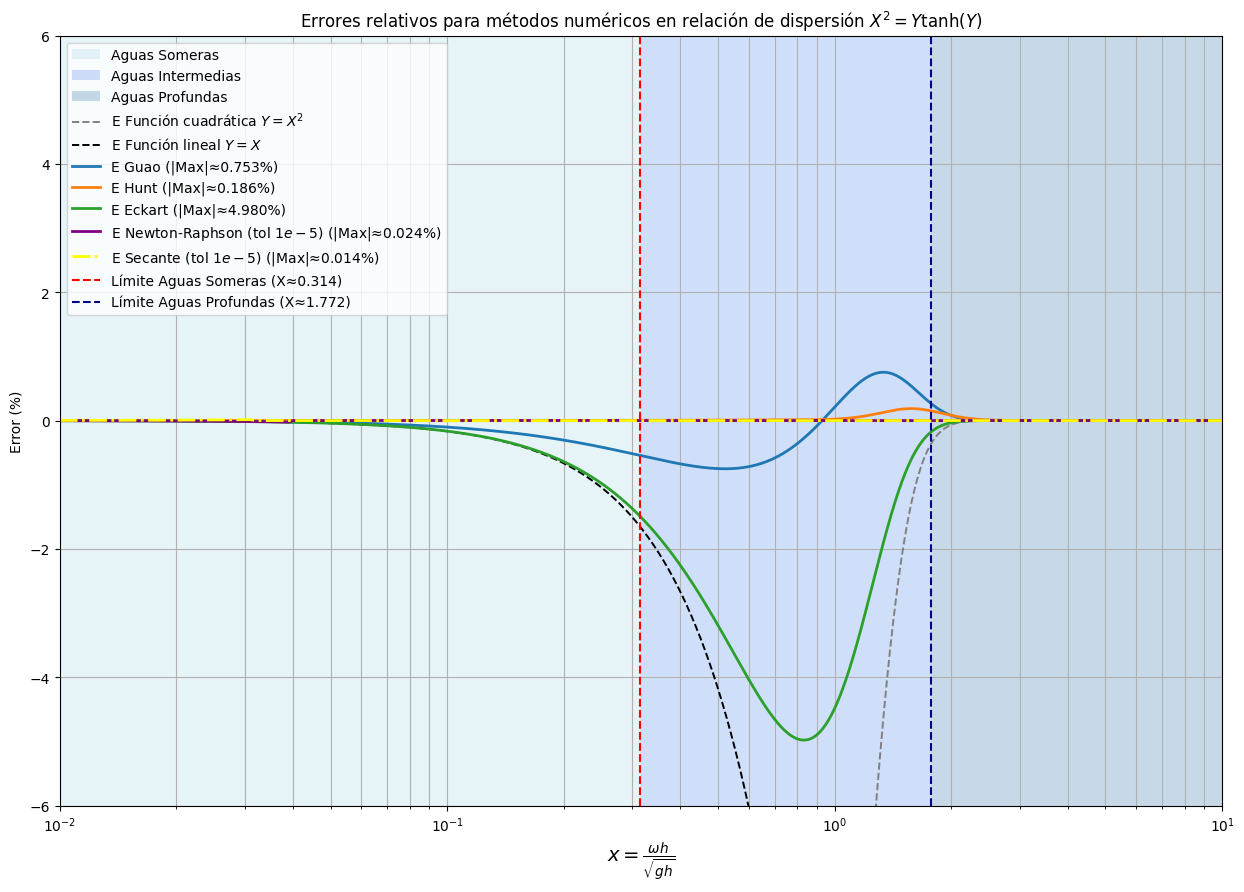

In [ ]:
plt.figure(figsize=(15, 10))
plt.axvspan(x_array.min(), x_lim_somera, facecolor='lightblue', alpha=0.3, label='Aguas Someras')
plt.axvspan(x_lim_somera, x_lim_profunda, facecolor='cornflowerblue', alpha=0.3, label='Aguas Intermedias')
plt.axvspan(x_lim_profunda, x_array.max(), facecolor='steelblue', alpha=0.3, label='Aguas Profundas')

plt.plot(x_array, error_array_y_x2, label='E Función cuadrática $Y = {X}^2$', linewidth=1.4, linestyle='--', color="grey")
plt.plot(x_array, error_array_y_x, label='E Función lineal $Y = X$', linewidth=1.4, linestyle='--', color="black")
plt.plot(x_array, error_array_guo, label=f'E Guao (|Max|≈{max_error_guo:.3f}%)', linewidth=2)
plt.plot(x_array, error_array_hunt, label=f'E Hunt (|Max|≈{max_error_hunt:.3f}%)', linewidth=2)
plt.plot(x_array, error_array_eckart, label=f'E Eckart (|Max|≈{max_error_eckart:.3f}%)', linewidth=2)
plt.plot(x_array, error_array_newton_raphson, label=f'E Newton-Raphson (tol $1e-5$) (|Max|≈{max_error_newton_raphson:.3f}%)', linewidth=2, color="purple")
plt.plot(x_array, error_array_secante, label=f'E Secante (tol $1e-5$) (|Max|≈{max_error_secante:.3f}%)', linestyle='-.', linewidth=2, color="yellow")

plt.xscale('log')
plt.axvline(x=x_lim_somera, color='red', linestyle='--', label=f'Límite Aguas Someras (X≈{x_lim_somera:.3f})')
plt.axvline(x=x_lim_profunda, color='darkblue', linestyle='--', label=f'Límite Aguas Profundas (X≈{x_lim_profunda:.3f})')
plt.xlabel(r'$x = \frac{\omega h}{\sqrt{gh}}$', fontsize=14)
plt.ylabel('Error (%)')
plt.title(r'Errores relativos para métodos numéricos en relación de dispersión $X^2 = Y \tanh(Y)$')
plt.xlim(x_array.min(), x_array.max())
plt.ylim(-6, 6)
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

En base a los resultados se obtienen los siguientes errores máximos absolutos:

Guao = $0.753 \%$

Hunt = $0.186 \%$

Eckart= $4.98 \%$

Newton-raphson= $0.024 \%$

Secante= $0.014 \%$

Las mejores aproximaciones son los métodos numéricos Newton raphson y Secante, ambos con tolerancia de 1e-5, para todo rango de la ecuación con un error de practicamente 0. Esto es de esperarse considerando que ambos son métodos que resuelven iterativamente la fórmula de dispersión, utilizando en el proceso grandes cantidades de procesamiento computacional (En relacion a las aproximaciones). Uno de los problemas que surge en estos métodos es la necesidad de tener un punto inicial (y otro final en caso de la secante) para empezar a iterar, añadiendo complejidad, más procesamiento y datos en caso de elegir un punto erroneo.

La aproximación de Hunt es uno de los mejores métodos aproximados con solo un error relativo de 0.186%, específicamente en el rango de aguas intermedias, cerca de la transición a aguas profundas. El porcentaje de error es positivo, por lo que se asume que es más conservador en relación al valor preciso. Uno de los problemas de este método es la sumatoria en el denominador de la ecuación por la cantidad de procesamiento, sin embargo, es ínfimo a la cantidad de procesamiento por métodos numéricos.

Guao obtiene un error máximo de 0.753% en la zona de aguas intermedias. Lo curioso es que dentro de este rango existen 2 puntos máximos de error, uno subestimando el valor en la zona de aguas intermedias más cercanas a someras, y otro máximo positivo sobrestimando el valor cerca de la transición a aguas profundas, generando una zona de alta precisión en la mitad del rango intermedio de aguas. La fórmula de aproximación sobresale por ser facil de usar y además tener un % de error muy bajo.

Finalmente tenemos el método de Eckart con el mayor porcentaje de error, con una diferencia notable en relación a los demás métodos (Como se ve en los gráficos de barra). Este método posee un error máximo en la mitad del rango de aguas intermedias con un valor negativo de casi 5%, subestimando el valor original. El error tambien se nota en la zona de aguas someras en transición a intermedias, sin embargo, en aguas profundas es prácticamente preciso.